In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from scipy.stats import kruskal

pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()


Dataset loaded successfully!
Rows: 4000
Columns: 28


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [8]:
print("Columns in the dataset:")
for i, column in enumerate(df.columns, 1):
    print(i, column)

Columns in the dataset:
1 Farm_ID
2 State
3 District
4 Crop
5 Season
6 Farm_Area_Hectares
7 Rainfall_mm
8 Avg_Temperature_C
9 Humidity_pct
10 Sunlight_Hours_Day
11 Soil_pH
12 Soil_Moisture_pct
13 Nitrogen_kg_ha
14 Phosphorus_kg_ha
15 Potassium_kg_ha
16 Irrigation_Method
17 Fertilizer_kg_ha
18 Pesticide_Litre_ha
19 Seed_Quality_Score
20 Yield_Tonnes_Ha
21 Production_Tonnes
22 Market_Price_INR_Tonne
23 Total_Cost_INR
24 Revenue_INR
25 Profit_INR
26 Water_Used_m3
27 Water_Efficiency_t_per_1000m3
28 Disease_Pest_Risk_pct


In [9]:
missing = df.isnull().sum() #Check missing values

print("Missing values:")
print(missing[missing > 0])

Missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [10]:
df_clean = df.copy()

# Fill numerical missing values using median
numeric_columns = df_clean.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

print("Missing values after cleaning:")
print(df_clean.isnull().sum().sum())

Missing values after cleaning:
0


In [11]:
#duplicates check
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [12]:
print(df_clean['Season'].value_counts())

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [13]:
season_summary = df_clean.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Profit_INR': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Revenue_INR,Total_Cost_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.63,46.31,178914.65,710719.06,531804.41,6102.20,5.89,54.47
Rabi,5.04,41.49,87689.47,601526.05,513836.58,5846.99,5.19,40.48
Zaid,4.64,38.89,-24804.82,519171.90,543976.73,6419.89,4.41,38.22


In [14]:
#Analyze yield by season
yield_season = df_clean.groupby('Season')['Yield_Tonnes_Ha'].agg(
    ['mean', 'median', 'min', 'max']
).round(2)

yield_season

,mean,median,min,max
Season,,,,
Kharif,5.63,1.94,0.3,101.44
Rabi,5.04,1.67,0.3,93.13
Zaid,4.64,1.46,0.3,64.76


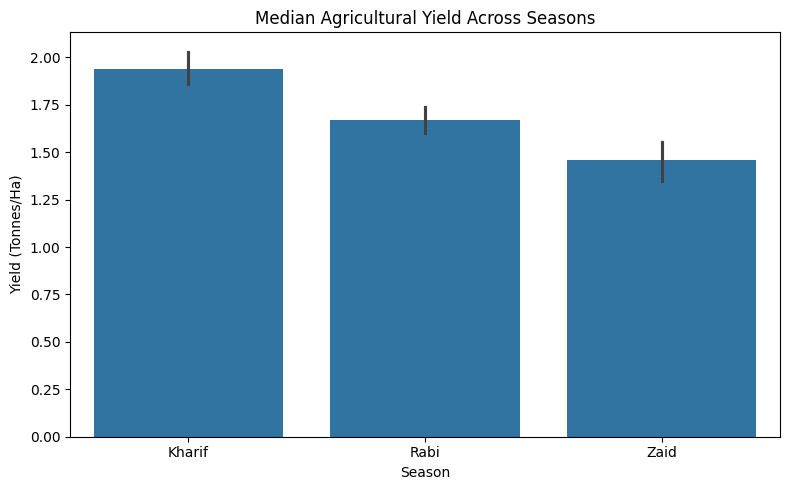

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='median'
)

plt.title('Median Agricultural Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

In [16]:
profit_season = df_clean.groupby('Season')['Profit_INR'].agg(
    ['mean', 'median', 'std']
).round(2)

profit_season

,mean,median,std
Season,,,
Kharif,178914.65,38808.0,611549.78
Rabi,87689.47,-3187.0,489901.25
Zaid,-24804.82,-62144.0,436356.75


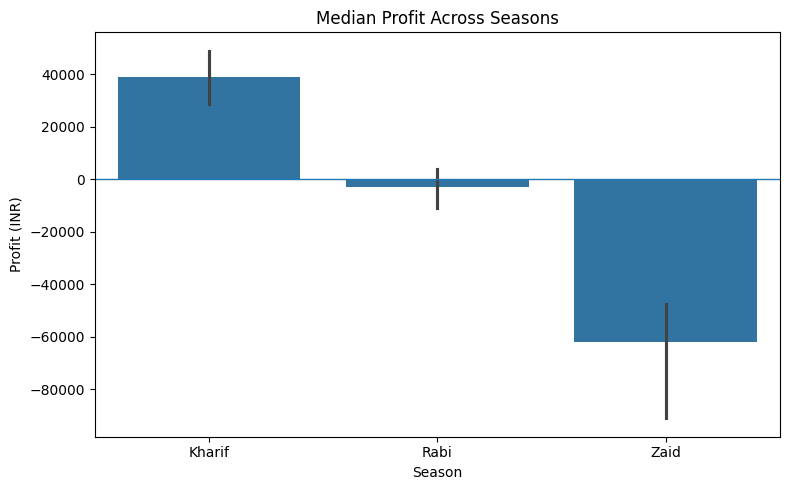

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Profit_INR',
    estimator='median'
)

plt.title('Median Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

In [19]:
#Analyze environmental conditions
environment_summary = df_clean.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Sunlight_Hours_Day': 'mean',
    'Soil_Moisture_pct': 'mean'
}).round(2)

environment_summary


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


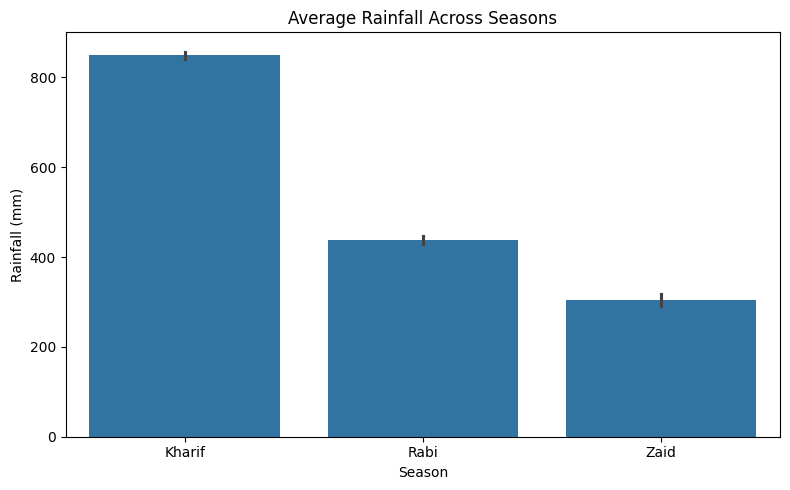

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Rainfall_mm'
)

plt.title('Average Rainfall Across Seasons')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')
plt.tight_layout()
plt.show()

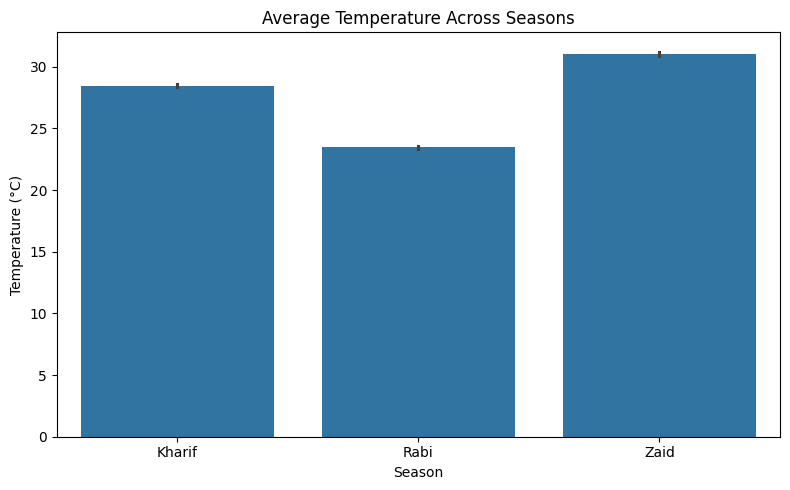

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Avg_Temperature_C'
)

plt.title('Average Temperature Across Seasons')
plt.xlabel('Season')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()


In [23]:
#Crop-wise seasonal analysis
crop_season = df_clean.groupby(
    ['Season', 'Crop']
)['Yield_Tonnes_Ha'].median().unstack()

crop_season.round(2)


Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,1.77,1.45,1.52,3.12,1.09,2.86,56.65,2.36
Rabi,1.58,1.21,1.31,2.78,0.90,2.37,45.21,2.22
Zaid,1.25,0.98,1.10,2.26,0.68,1.94,38.78,1.84


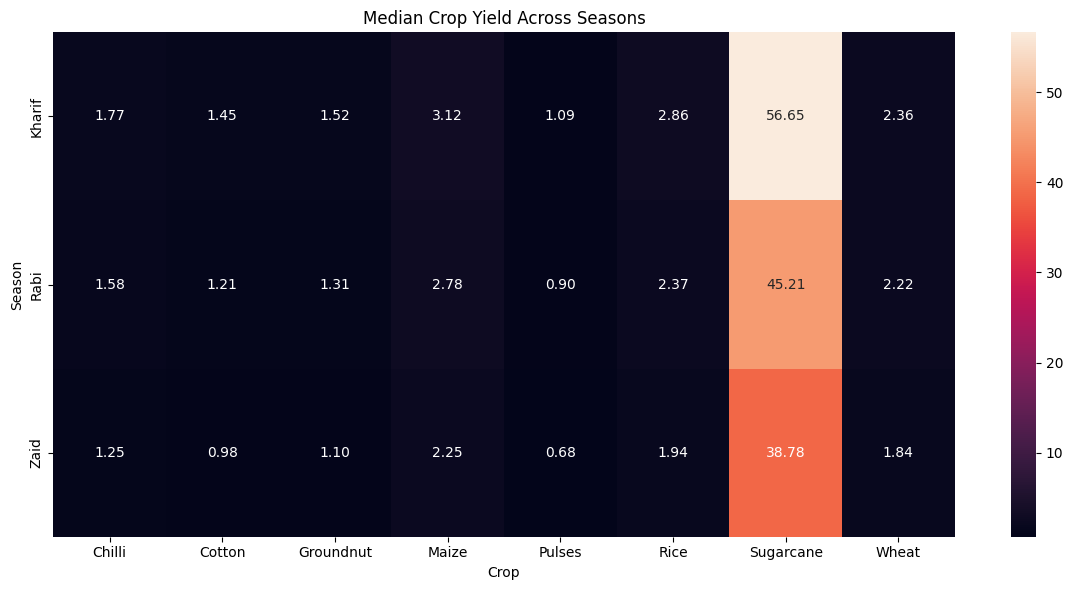

In [24]:
plt.figure(figsize=(12,6))

sns.heatmap(
    crop_season,
    annot=True,
    fmt='.2f'
)

plt.title('Median Crop Yield Across Seasons')
plt.xlabel('Crop')
plt.ylabel('Season')
plt.tight_layout()
plt.show()

In [25]:
#Irrigation analysis
irrigation_season = pd.crosstab(
    df_clean['Season'],
    df_clean['Irrigation_Method'],
    normalize='index'
) * 100

irrigation_season.round(2)


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


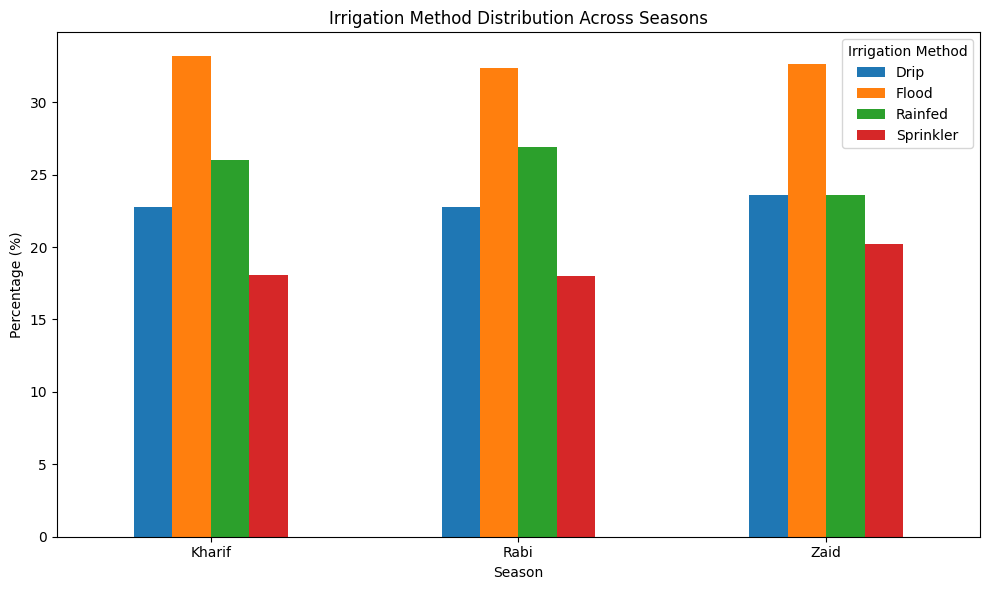

In [26]:
irrigation_season.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Irrigation Method Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Irrigation Method')
plt.tight_layout()
plt.show()

In [27]:
#Water efficiency
water_summary = df_clean.groupby('Season').agg({
    'Water_Used_m3': 'median',
    'Water_Efficiency_t_per_1000m3': 'median'
}).round(2)

water_summary

,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,4469.0,3.28
Rabi,4292.0,2.74
Zaid,4805.0,2.30


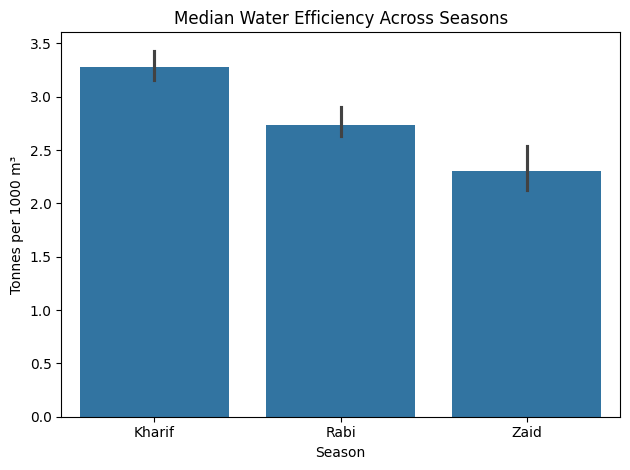

In [28]:
#plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Water_Efficiency_t_per_1000m3',
    estimator='median'
)

plt.title('Median Water Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Tonnes per 1000 m³')
plt.tight_layout()
plt.show()

In [29]:
#Disease and pest risk
risk_summary = df_clean.groupby('Season')[
    'Disease_Pest_Risk_pct'
].agg(['mean', 'median']).round(2)

risk_summary

,mean,median
Season,,
Kharif,54.47,54.5
Rabi,40.48,40.6
Zaid,38.22,37.9


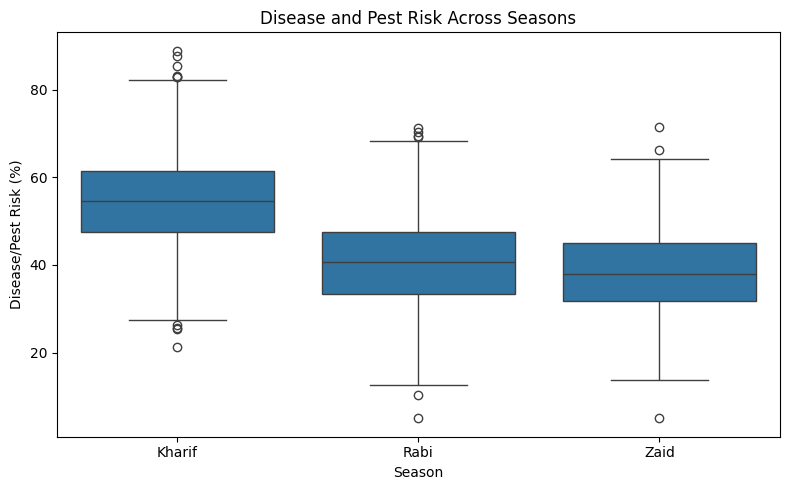

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Disease_Pest_Risk_pct'
)

plt.title('Disease and Pest Risk Across Seasons')
plt.xlabel('Season')
plt.ylabel('Disease/Pest Risk (%)')
plt.tight_layout()
plt.show()

In [31]:
#Relationship analysis
correlation_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct',
    'Profit_INR'
]

corr = df_clean[correlation_columns].corr()

corr.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_INR
Rainfall_mm,1.00,0.20,0.52,0.51,0.02,0.00,-0.02,0.03,0.00,0.06,0.62,0.11
Avg_Temperature_C,0.20,1.00,0.14,0.08,0.02,0.01,-0.03,0.01,0.02,0.01,0.25,0.01
Humidity_pct,0.52,0.14,1.00,0.45,0.02,-0.00,-0.05,0.01,-0.00,0.03,0.55,0.06
Soil_Moisture_pct,0.51,0.08,0.45,1.00,0.01,-0.02,-0.02,0.01,0.00,0.03,0.38,0.09
Fertilizer_kg_ha,0.02,0.02,0.02,0.01,1.00,-0.00,0.02,0.00,0.00,0.01,0.02,-0.07
Pesticide_Litre_ha,0.00,0.01,-0.00,-0.02,-0.00,1.00,-0.00,-0.01,0.00,-0.01,-0.47,-0.03
Seed_Quality_Score,-0.02,-0.03,-0.05,-0.02,0.02,-0.00,1.00,-0.01,0.02,-0.01,-0.02,0.01
Yield_Tonnes_Ha,0.03,0.01,0.01,0.01,0.00,-0.01,-0.01,1.00,0.39,0.91,0.01,0.49
Water_Used_m3,0.00,0.02,-0.00,0.00,0.00,0.00,0.02,0.39,1.00,0.22,0.01,0.19
Water_Efficiency_t_per_1000m3,0.06,0.01,0.03,0.03,0.01,-0.01,-0.01,0.91,0.22,1.00,0.03,0.49


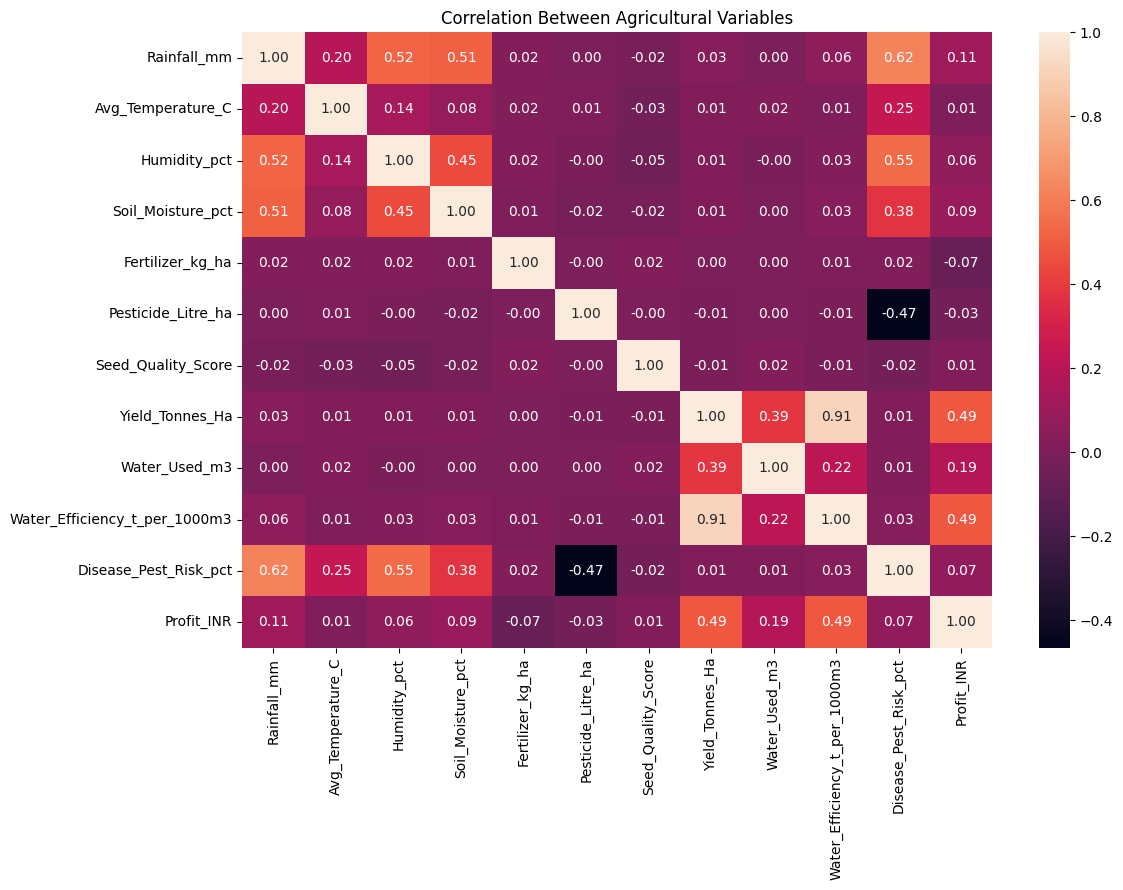

In [32]:
plt.figure(figsize=(12,9))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Between Agricultural Variables')
plt.tight_layout()
plt.show()

In [33]:
#Statistical test
kharif = df_clean[df_clean['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi = df_clean[df_clean['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid = df_clean[df_clean['Season'] == 'Zaid']['Yield_Tonnes_Ha']

stat, p_value = kruskal(kharif, rabi, zaid)

print("Kruskal-Wallis Statistic:", stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: Yield differences across seasons are statistically significant.")
else:
    print("Result: No statistically significant difference was detected.")

Kruskal-Wallis Statistic: 68.71306722231378
p-value: 1.1999054760748268e-15
Result: Yield differences across seasons are statistically significant.


In [34]:
#Create a final summary table
final_summary = df_clean.groupby('Season').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Median_Yield=('Yield_Tonnes_Ha', 'median'),
    Average_Profit=('Profit_INR', 'mean'),
    Median_Profit=('Profit_INR', 'median'),
    Average_Rainfall=('Rainfall_mm', 'mean'),
    Average_Temperature=('Avg_Temperature_C', 'mean'),
    Median_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'median'),
    Average_Pest_Risk=('Disease_Pest_Risk_pct', 'mean')
).round(2)

final_summary

,Average_Yield,Median_Yield,Average_Profit,Median_Profit,Average_Rainfall,Average_Temperature,Median_Water_Efficiency,Average_Pest_Risk
Season,,,,,,,,
Kharif,5.63,1.94,178914.65,38808.0,849.20,28.45,3.28,54.47
Rabi,5.04,1.67,87689.47,-3187.0,437.62,23.49,2.74,40.48
Zaid,4.64,1.46,-24804.82,-62144.0,304.65,31.04,2.30,38.22


In [35]:
from scipy.stats import kruskal

kharif = df_clean[df_clean['Season']=='Kharif']['Yield_Tonnes_Ha']
rabi = df_clean[df_clean['Season']=='Rabi']['Yield_Tonnes_Ha']
zaid = df_clean[df_clean['Season']=='Zaid']['Yield_Tonnes_Ha']

stat, p_value = kruskal(kharif, rabi, zaid)

print("Statistic:", stat)
print("p-value:", p_value)

Statistic: 68.71306722231378
p-value: 1.1999054760748268e-15
